In [1]:
import numpy as np
import pandas as pd

# Load dataset
solar_data = pd.read_csv('SOLAR_PLANT_DATA(GENERATION_AND_WEATHER).csv')
solar_data['DATE_TIME'] = pd.to_datetime(solar_data['DATE_TIME'])

# Cyclical Features
time_float = (
    solar_data['DATE_TIME'].dt.hour + solar_data['DATE_TIME'].dt.minute / 60.0
)
solar_data['TIME_OF_DAY_SIN'] = np.sin(2 * np.pi * time_float / 24.0)
solar_data['TIME_OF_DAY_COS'] = np.cos(2 * np.pi * time_float / 24.0)
day_of_year = solar_data['DATE_TIME'].dt.dayofyear
solar_data['DAY_OF_YEAR_SIN'] = np.sin(2 * np.pi * day_of_year / 365.25)
solar_data['DAY_OF_YEAR_COS'] = np.cos(2 * np.pi * day_of_year / 365.25)

# --- Derive a real plant capacity instead of trusting CALCULATED_PLANT_CAPACITY(kWp) ---
# (THEORETICAL_AC_PER_KWP > 0.5, avoiding noisy near zero denominators), the ratio
# ACTUAL_AC_POWER / THEORETICAL_AC_PER_KWP tells us what capacity would make the real
# data lands on a 0-1 scale. We take the median of that ratio as a robust estimate.
capacity_estimation_mask = solar_data['THEORETICAL_AC_PER_KWP'] > 0.5
implied_capacity_kwp = (
    solar_data.loc[capacity_estimation_mask, 'ACTUAL_AC_POWER(kW)']
    / solar_data.loc[capacity_estimation_mask, 'THEORETICAL_AC_PER_KWP']
).median()

print(f"Stated CALCULATED_PLANT_CAPACITY(kWp): {solar_data['CALCULATED_PLANT_CAPACITY(kWp)'].iloc[0]:.1f}")
print(f"Derived capacity estimate (median, n={capacity_estimation_mask.sum()} rows): {implied_capacity_kwp:.1f}")

# Scale Target to per-kWp Capacity (Capacity Agnostic Gap Metric)
# Actual Capacity Factor
solar_data['ACTUAL_AC_PER_KWP'] = (
    solar_data['ACTUAL_AC_POWER(kW)'] / implied_capacity_kwp
)
# Target Variable (Gap Error)
solar_data['TARGET_GAP_PER_KWP'] = (
    solar_data['ACTUAL_AC_PER_KWP'] - solar_data['THEORETICAL_AC_PER_KWP']
)

# Sanity check: this should now be small (roughly -1 to 1), not the 4.8 mean / 25 max we saw before
print(f"\nTARGET_GAP_PER_KWP stats: mean={solar_data['TARGET_GAP_PER_KWP'].mean():.4f}, "
      f"std={solar_data['TARGET_GAP_PER_KWP'].std():.4f}, "
      f"min={solar_data['TARGET_GAP_PER_KWP'].min():.4f}, "
      f"max={solar_data['TARGET_GAP_PER_KWP'].max():.4f}")

# Feature Matrix and Target Vector
features = [
    'IRRADIATION(W/m²)',
    'AMBIENT_TEMPERATURE(°C)',
    'WIND_SPEED(m/s)',
    'CLOUD_COVER(%)',
    'TIME_OF_DAY_SIN',
    'TIME_OF_DAY_COS',
    'DAY_OF_YEAR_SIN',
    'DAY_OF_YEAR_COS',
]
X = solar_data[features]
y = solar_data['TARGET_GAP_PER_KWP']
print(f'\nDataset ready: {X.shape[0]} rows, {X.shape[1]} features.')

Stated CALCULATED_PLANT_CAPACITY(kWp): 1000.0
Derived capacity estimate (median, n=660 rows): 20230.2

TARGET_GAP_PER_KWP stats: mean=0.0331, std=0.1212, min=-0.6784, max=0.4362

Dataset ready: 3259 rows, 8 features.


In [2]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, solar_data.index, test_size=0.2, random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
xgb_model.fit(X_train, y_train)

pred_test_gap = xgb_model.predict(X_test)

test_rmse = mean_squared_error(y_test, pred_test_gap) ** 0.5
test_mae = mean_absolute_error(y_test, pred_test_gap)
test_r2 = r2_score(y_test, pred_test_gap)

print("=== 80/20 Holdout ===")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")

=== 80/20 Holdout ===
RMSE: 0.0492
MAE:  0.0206
R2:   0.8132


In [3]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

cv_neg_rmse = cross_val_score(cv_model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
cv_rmse = -cv_neg_rmse
cv_mae = -cross_val_score(cv_model, X, y, cv=kf, scoring='neg_mean_absolute_error')
cv_r2 = cross_val_score(cv_model, X, y, cv=kf, scoring='r2')

print("=== 5-Fold Cross-Validation ===")
for fold_i in range(5):
    print(f"Fold {fold_i + 1}: RMSE={cv_rmse[fold_i]:.4f}  MAE={cv_mae[fold_i]:.4f}  R2={cv_r2[fold_i]:.4f}")

print(f"\nMean RMSE: {cv_rmse.mean():.4f}  (std: {cv_rmse.std():.4f})")
print(f"Mean MAE:  {cv_mae.mean():.4f}  (std: {cv_mae.std():.4f})")
print(f"Mean R2:   {cv_r2.mean():.4f}  (std: {cv_r2.std():.4f})")

=== 5-Fold Cross-Validation ===
Fold 1: RMSE=0.0502  MAE=0.0210  R2=0.8056
Fold 2: RMSE=0.0556  MAE=0.0234  R2=0.7984
Fold 3: RMSE=0.0557  MAE=0.0229  R2=0.7766
Fold 4: RMSE=0.0585  MAE=0.0256  R2=0.7779
Fold 5: RMSE=0.0765  MAE=0.0275  R2=0.6266

Mean RMSE: 0.0593  (std: 0.0090)
Mean MAE:  0.0241  (std: 0.0023)
Mean R2:   0.7570  (std: 0.0662)


In [4]:
# get the efficiency rate per panel unit and multiply that rate by plant's total capacity
def predict_combined_ac_per_kwp(model, X_rows, irradiation_values, theoretical_ac_per_kwp_values):
    """
    Combine the physics baseline with the model's predicted gap to get the
    final per-kWp AC output, applying the midnight override and a zero floor.
    """
    predicted_gap = model.predict(X_rows)
    combined = np.asarray(theoretical_ac_per_kwp_values) + predicted_gap
    combined = np.where(np.asarray(irradiation_values) <= 0, 0.0, combined)
    combined = np.maximum(combined, 0.0)
    return combined, predicted_gap


def predict_combined_ac_kw(model, X_rows, irradiation_values, theoretical_ac_per_kwp_values, capacity_kwp):
    combined_per_kwp, predicted_gap = predict_combined_ac_per_kwp(
        model, X_rows, irradiation_values, theoretical_ac_per_kwp_values
    )
    return combined_per_kwp * capacity_kwp, predicted_gap

In [5]:
# Mirrors physicsCalc.py
STC_IRRADIANCE = 1000
STC_TEMP = 25
DEFAULT_TEMP_COEFF = -0.004
DEFAULT_NOCT = 45
DEFAULT_INVERTER_EFF = 0.97


def estimate_module_temperature(ambient_temp_c, irradiance_wm2, wind_speed_ms=None, noct=DEFAULT_NOCT):
    if wind_speed_ms is not None and not pd.isna(wind_speed_ms):
        u0, u1 = 25.0, 6.84
        delta_t = irradiance_wm2 / (u0 + u1 * wind_speed_ms)
    else:
        delta_t = (noct - 20) * (irradiance_wm2 / 800.0)
    return ambient_temp_c + delta_t


def calculate_dc_power_per_kwp(irradiance_wm2, module_temp_c, temp_coefficient=DEFAULT_TEMP_COEFF):
    if irradiance_wm2 <= 0:
        return 0.0
    irradiance_ratio = irradiance_wm2 / STC_IRRADIANCE
    temp_adjustment = 1 + temp_coefficient * (module_temp_c - STC_TEMP)
    return max(irradiance_ratio * temp_adjustment, 0.0)


def calculate_ac_power_per_kwp(dc_power_per_kwp, inverter_efficiency=DEFAULT_INVERTER_EFF):
    return dc_power_per_kwp * inverter_efficiency


def build_feature_row(irradiation, ambient_temp, wind_speed, cloud_cover, hour, day_of_year_val):
    time_f = hour
    return pd.DataFrame([{
        'IRRADIATION(W/m²)': irradiation,
        'AMBIENT_TEMPERATURE(°C)': ambient_temp,
        'WIND_SPEED(m/s)': wind_speed,
        'CLOUD_COVER(%)': cloud_cover,
        'TIME_OF_DAY_SIN': np.sin(2 * np.pi * time_f / 24.0),
        'TIME_OF_DAY_COS': np.cos(2 * np.pi * time_f / 24.0),
        'DAY_OF_YEAR_SIN': np.sin(2 * np.pi * day_of_year_val / 365.25),
        'DAY_OF_YEAR_COS': np.cos(2 * np.pi * day_of_year_val / 365.25),
    }])[features]


# --- Check 1: zero irradiation -> zero combined output ---
night_row = build_feature_row(
    irradiation=0.0, ambient_temp=22.0, wind_speed=3.0, cloud_cover=50.0,
    hour=2, day_of_year_val=150,
)
night_combined, night_gap = predict_combined_ac_per_kwp(
    xgb_model, night_row, [0.0], [0.0]
)
print(f"Check 1 - Zero irradiation -> combined output: {night_combined[0]:.6f} "
      f"(raw model gap prediction was {night_gap[0]:.4f}, overridden to 0)")
assert night_combined[0] == 0.0, "FAILED: non-zero output at zero irradiation"
print("PASSED\n")

# --- Check 2: cooler panel produces more output than hotter panel, same irradiance ---
irr_fixed = 900.0
wind_fixed = 2.5
hour_fixed = 12
doy_fixed = 150

cool_ambient, hot_ambient = 18.0, 42.0

cool_row = build_feature_row(irr_fixed, cool_ambient, wind_fixed, 20.0, hour_fixed, doy_fixed)
hot_row = build_feature_row(irr_fixed, hot_ambient, wind_fixed, 20.0, hour_fixed, doy_fixed)

cool_mod_temp = estimate_module_temperature(cool_ambient, irr_fixed, wind_fixed)
hot_mod_temp = estimate_module_temperature(hot_ambient, irr_fixed, wind_fixed)
cool_theo_ac = calculate_ac_power_per_kwp(calculate_dc_power_per_kwp(irr_fixed, cool_mod_temp))
hot_theo_ac = calculate_ac_power_per_kwp(calculate_dc_power_per_kwp(irr_fixed, hot_mod_temp))

cool_combined, _ = predict_combined_ac_per_kwp(xgb_model, cool_row, [irr_fixed], [cool_theo_ac])
hot_combined, _ = predict_combined_ac_per_kwp(xgb_model, hot_row, [irr_fixed], [hot_theo_ac])

print(f"Check 2 - Same irradiance ({irr_fixed} W/m²), ambient {cool_ambient}°C vs {hot_ambient}°C")
print(f"  Module temp:      cool={cool_mod_temp:.1f}°C   hot={hot_mod_temp:.1f}°C")
print(f"  Combined AC/kWp:  cool={cool_combined[0]:.4f}   hot={hot_combined[0]:.4f}")
assert cool_combined[0] > hot_combined[0], "FAILED: hotter panel did not produce less output"
print("PASSED")


Check 1 - Zero irradiation -> combined output: 0.000000 (raw model gap prediction was -0.0033, overridden to 0)
PASSED

Check 2 - Same irradiance (900.0 W/m²), ambient 18.0°C vs 42.0°C
  Module temp:      cool=39.4°C   hot=63.4°C
  Combined AC/kWp:  cool=0.5457   hot=0.4709
PASSED


--- Backtest ---
RMSE: 994.4 kW
MAE:  393.9 kW
R2:   0.9761
Residual mean: 119.4 kW  (should be close to 0, no systematic bias)
Residual std:  987.2 kW


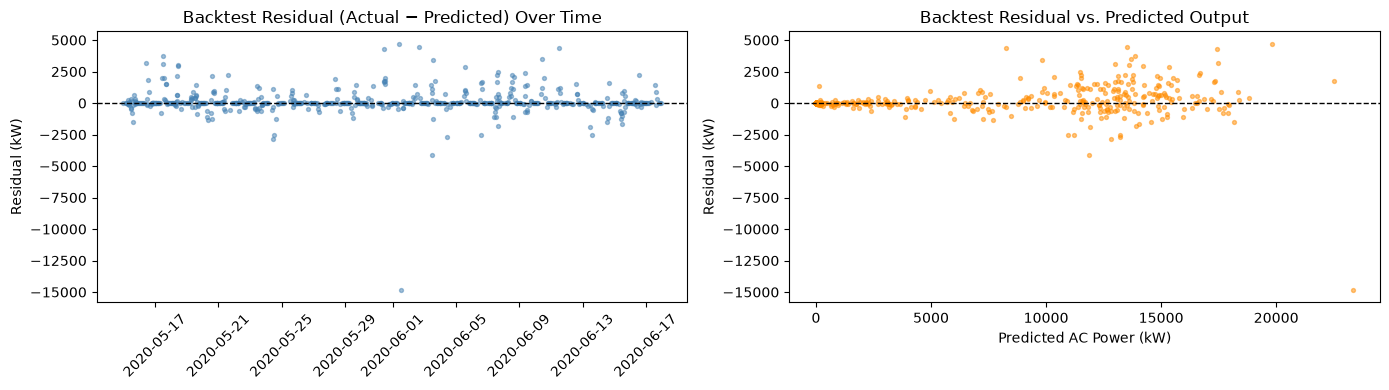

In [6]:
# Asks the XGBoost model to predict the gap error where we then add that correction to the physics model to scale it
# Then measures the gap error with accuracy scores and plots
import matplotlib.pyplot as plt

theo_ac_test = solar_data.loc[idx_test, 'THEORETICAL_AC_PER_KWP'].values
irr_test = solar_data.loc[idx_test, 'IRRADIATION(W/m²)'].values
actual_kw_test = solar_data.loc[idx_test, 'ACTUAL_AC_POWER(kW)'].values
datetime_test = solar_data.loc[idx_test, 'DATE_TIME'].values

combined_kw_test, _ = predict_combined_ac_kw(
    xgb_model, X_test, irr_test, theo_ac_test, implied_capacity_kwp
)

residual_kw = actual_kw_test - combined_kw_test

backtest_rmse_kw = mean_squared_error(actual_kw_test, combined_kw_test) ** 0.5
backtest_mae_kw = mean_absolute_error(actual_kw_test, combined_kw_test)
backtest_r2_kw = r2_score(actual_kw_test, combined_kw_test)

print("--- Backtest ---")
print(f"RMSE: {backtest_rmse_kw:.1f} kW")
print(f"MAE:  {backtest_mae_kw:.1f} kW")
print(f"R2:   {backtest_r2_kw:.4f}")
print(f"Residual mean: {residual_kw.mean():.1f} kW  (should be close to 0, no systematic bias)")
print(f"Residual std:  {residual_kw.std():.1f} kW")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

order = np.argsort(datetime_test)
axes[0].scatter(datetime_test[order], residual_kw[order], s=8, alpha=0.5, color='steelblue')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Backtest Residual (Actual − Predicted) Over Time')
axes[0].set_ylabel('Residual (kW)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].scatter(combined_kw_test, residual_kw, s=8, alpha=0.5, color='darkorange')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Backtest Residual vs. Predicted Output')
axes[1].set_xlabel('Predicted AC Power (kW)')
axes[1].set_ylabel('Residual (kW)')

plt.tight_layout()
plt.show()


In [7]:
# Summary
print("=" * 70)
print("FINAL MODEL ACCURACY SUMMARY")
print("=" * 70)
print(f"Derived plant capacity used for scaling: {implied_capacity_kwp:.1f} kWp")
print()
print("80/20 Holdout (TARGET_GAP_PER_KWP):")
print(f"  RMSE={test_rmse:.4f}  MAE={test_mae:.4f}  R2={test_r2:.4f}")
print()
print("5-Fold Cross-Validation (TARGET_GAP_PER_KWP):")
print(f"  RMSE mean={cv_rmse.mean():.4f} (std={cv_rmse.std():.4f})")
print(f"  MAE  mean={cv_mae.mean():.4f} (std={cv_mae.std():.4f})")
print(f"  R2   mean={cv_r2.mean():.4f} (std={cv_r2.std():.4f})")
print()
print("Backtest on held out data, reconstructed to real AC power (kW):")
print(f"  RMSE={backtest_rmse_kw:.1f} kW   MAE={backtest_mae_kw:.1f} kW   R2={backtest_r2_kw:.4f}")
print(f"  Residual mean={residual_kw.mean():.1f} kW (bias check, should be ~0)")
print()
print("Checks: PASSED (zero irradiation override, cooler panel produces more)")
print("=" * 70)
print("Reminder for the confidence indicator: this model was trained on 34 days")
print("from one region in May-June (monsoon season). Report these numbers as is,")
print("and pair them with the out of range warning for conditions far outside that window.")


FINAL MODEL ACCURACY SUMMARY
Derived plant capacity used for scaling: 20230.2 kWp

80/20 Holdout (TARGET_GAP_PER_KWP):
  RMSE=0.0492  MAE=0.0206  R2=0.8132

5-Fold Cross-Validation (TARGET_GAP_PER_KWP):
  RMSE mean=0.0593 (std=0.0090)
  MAE  mean=0.0241 (std=0.0023)
  R2   mean=0.7570 (std=0.0662)

Backtest on held out data, reconstructed to real AC power (kW):
  RMSE=994.4 kW   MAE=393.9 kW   R2=0.9761
  Residual mean=119.4 kW (bias check, should be ~0)

Checks: PASSED (zero irradiation override, cooler panel produces more)
Reminder for the confidence indicator: this model was trained on 34 days
from one region in May-June (monsoon season). Report these numbers as is,
and pair them with the out of range warning for conditions far outside that window.


In [8]:
# Final production model
import joblib

final_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
final_model.fit(X, y)

joblib.dump(final_model, 'solar_gap_model.joblib')

model_metadata = {
    'feature_order': features,
    'implied_capacity_kwp': float(implied_capacity_kwp),
    'target_column': 'TARGET_GAP_PER_KWP',
    'combination_rule': (
        'combined_ac_per_kwp = max(THEORETICAL_AC_PER_KWP + predicted_gap, 0); '
        'forced to 0 whenever IRRADIATION(W/m²) <= 0 (midnight override); '
        'combined_ac_kw = combined_ac_per_kwp * capacity_kwp'
    ),
    'training_window': 'May 15 - Jun 17 2020, single plant, single region (monsoon season)',
    'holdout_test_rmse_gap_per_kwp': float(test_rmse),
    'holdout_test_mae_gap_per_kwp': float(test_mae),
    'holdout_test_r2_gap_per_kwp': float(test_r2),
    'cv_rmse_mean_gap_per_kwp': float(cv_rmse.mean()),
    'cv_rmse_std_gap_per_kwp': float(cv_rmse.std()),
    'backtest_rmse_kw': float(backtest_rmse_kw),
    'backtest_mae_kw': float(backtest_mae_kw),
    'backtest_r2_kw': float(backtest_r2_kw),
}

import json as _json
with open('solar_gap_model_metadata.json', 'w') as f:
    _json.dump(model_metadata, f, indent=2)

print("Saved: solar_gap_model.joblib")
print("Saved: solar_gap_model_metadata.json")
print()
print(_json.dumps(model_metadata, indent=2))

Saved: solar_gap_model.joblib
Saved: solar_gap_model_metadata.json

{
  "feature_order": [
    "IRRADIATION(W/m\u00b2)",
    "AMBIENT_TEMPERATURE(\u00b0C)",
    "WIND_SPEED(m/s)",
    "CLOUD_COVER(%)",
    "TIME_OF_DAY_SIN",
    "TIME_OF_DAY_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS"
  ],
  "implied_capacity_kwp": 20230.175625332173,
  "target_column": "TARGET_GAP_PER_KWP",
  "combination_rule": "combined_ac_per_kwp = max(THEORETICAL_AC_PER_KWP + predicted_gap, 0); forced to 0 whenever IRRADIATION(W/m\u00b2) <= 0 (midnight override); combined_ac_kw = combined_ac_per_kwp * capacity_kwp",
  "training_window": "May 15 - Jun 17 2020, single plant, single region (monsoon season)",
  "holdout_test_rmse_gap_per_kwp": 0.04920864455300208,
  "holdout_test_mae_gap_per_kwp": 0.02064737195563109,
  "holdout_test_r2_gap_per_kwp": 0.8131592935180025,
  "cv_rmse_mean_gap_per_kwp": 0.059295132826113386,
  "cv_rmse_std_gap_per_kwp": 0.009033002540117602,
  "backtest_rmse_kw": 994.4423620570526,

In [9]:
# Function to build and collect user inputs
# Location, plant capacity, and time is required, everything else is optional and defaults to a standard value
def build_user_inputs(location, capacity_kwp, time_range_days,
                       tilt_deg=None, azimuth_deg=None, inverter_efficiency=None,
                       temp_coefficient=None, degradation_pct_per_year=None):
    if location is None or str(location).strip() == '':
        raise ValueError("location is required. There is no reasonable default for where a system is.")
    if capacity_kwp is None:
        raise ValueError("capacity_kwp is required.   There is no reasonable default for system size.")
    if time_range_days is None:
        raise ValueError("time_range_days is required.The user must choose an estimate horizon.")

    return {
        'location': {'value': location, 'was_defaulted': False, 'note': 'User provided location.'},
        'capacity_kwp': {'value': capacity_kwp, 'was_defaulted': False, 'note': 'User provided system size.'},
        'time_range_days': {'value': time_range_days, 'was_defaulted': False, 'note': 'User-chosen estimate horizon.'},
        'tilt_deg': ({'value': tilt_deg, 'was_defaulted': False, 'note': 'User provided panel tilt.'}
                     if tilt_deg is not None else
                     {'value': None, 'was_defaulted': True,
                      'note': "Defaults to the location's latitude once geocoded."}),
        'azimuth_deg': ({'value': azimuth_deg, 'was_defaulted': False, 'note': 'User provided panel azimuth.'}
                        if azimuth_deg is not None else
                        {'value': None, 'was_defaulted': True,
                         'note': 'Defaults to true south (0 deg) in the northern hemisphere or true north '
                                 '(180 deg) in the southern hemisphere.'}),
        'inverter_efficiency': ({'value': inverter_efficiency, 'was_defaulted': False,
                                  'note': 'User provided inverter efficiency.'}
                                 if inverter_efficiency is not None else
                                 {'value': DEFAULT_INVERTER_EFF, 'was_defaulted': True,
                                  'note': f'Defaults to a typical inverter efficiency of {DEFAULT_INVERTER_EFF*100:.0f}%.'}),
        'temp_coefficient': ({'value': temp_coefficient, 'was_defaulted': False,
                               'note': 'User provided temperature coefficient.'}
                              if temp_coefficient is not None else
                              {'value': DEFAULT_TEMP_COEFF, 'was_defaulted': True,
                               'note': 'Defaults to a typical crystalline silicon value (~-0.4%/deg C).'}),
        'degradation_pct_per_year': ({'value': degradation_pct_per_year, 'was_defaulted': False,
                                       'note': 'User provided degradation rate.'}
                                      if degradation_pct_per_year is not None else
                                      {'value': 0.0, 'was_defaulted': True,
                                       'note': 'Defaults to treating the system as new, with no degradation applied.'}),
    }

# --- Example request ---
USER_TIER = 'advanced'   # 'simple' or 'advanced' -- controls language and which panels show
USER_INPUTS = build_user_inputs(
    location="Chennai, India", # string (geocoded below) or an (lat, lon) tuple
    capacity_kwp=5000.0,
    time_range_days=14,  # <= 10 -> real forecast; > 10 -> historical-years-based estimate
    degradation_pct_per_year=0.5,  # example: user provided this one, left the rest blank
)
print("USER_INPUTS collected. Required fields present; optional blanks will use defaults noted above.")


USER_INPUTS collected. Required fields present; optional blanks will use defaults noted above.


In [10]:
# Converts the user's location into real coordinates using the weather api
import requests

GEOCODING_URL = "https://geocoding-api.open-meteo.com/v1/search"

def geocode_location(location_str):
    resp = requests.get(GEOCODING_URL, params={'name': location_str, 'count': 1}, timeout=10)
    resp.raise_for_status()
    results = resp.json().get('results')
    if not results:
        raise ValueError(f"Could not geocode location: {location_str!r}")
    top = results[0]
    return top['latitude'], top['longitude'], top.get('name', location_str), top.get('timezone', 'auto')

if isinstance(USER_INPUTS['location']['value'], str):
    resolved_lat, resolved_lon, resolved_name, resolved_tz = geocode_location(USER_INPUTS['location']['value'])
else:
    resolved_lat, resolved_lon = USER_INPUTS['location']['value']
    resolved_name, resolved_tz = str(USER_INPUTS['location']['value']), 'auto'

print(f"Resolved location: {resolved_name} -> lat={resolved_lat:.4f}, lon={resolved_lon:.4f}, tz={resolved_tz}")

# Resolve the location dependent defaults now that coordinates exist
if USER_INPUTS['tilt_deg']['was_defaulted']:
    USER_INPUTS['tilt_deg']['value'] = round(abs(resolved_lat), 1)
    USER_INPUTS['tilt_deg']['note'] += f" Set to {USER_INPUTS['tilt_deg']['value']} deg (this location's latitude)."

if USER_INPUTS['azimuth_deg']['was_defaulted']:
    USER_INPUTS['azimuth_deg']['value'] = 0.0 if resolved_lat >= 0 else 180.0
    hemisphere = 'northern (south facing, 0 deg)' if resolved_lat >= 0 else 'southern (north facing, 180 deg)'
    USER_INPUTS['azimuth_deg']['note'] += f" Set to {USER_INPUTS['azimuth_deg']['value']} deg -- {hemisphere} hemisphere default."

print(f"Tilt: {USER_INPUTS['tilt_deg']['value']} deg | Azimuth: {USER_INPUTS['azimuth_deg']['value']} deg "
      f"(Open-Meteo convention: 0=S, -90=E, 90=W, 180=N)")

Resolved location: Chennai -> lat=13.0878, lon=80.2785, tz=Asia/Kolkata
Tilt: 13.1 deg | Azimuth: 0.0 deg (Open-Meteo convention: 0=S, -90=E, 90=W, 180=N)


In [11]:
# Branches on the user's chosen time and day range
# <= 10 calls the forecast API for those dates
# > 10 calls the historical archive API, pulling up to 10 past years of real weather for the matching calendar window
from datetime import date, timedelta

FORECAST_URL = "https://api.open-meteo.com/v1/forecast"
ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"
HOURLY_VARS = "temperature_2m,wind_speed_10m,cloud_cover,global_tilted_irradiance"
SHORT_TERM_MAX_DAYS = 10  # 1-10 days -> real forecast; beyond that -> historical archive


def _hourly_json_to_df(payload):
    hourly = payload['hourly']
    return pd.DataFrame({
        'DATE_TIME': pd.to_datetime(hourly['time']),
        'IRRADIATION(W/m²)': hourly['global_tilted_irradiance'],
        'AMBIENT_TEMPERATURE(°C)': hourly['temperature_2m'],
        'WIND_SPEED(m/s)': hourly['wind_speed_10m'],
        'CLOUD_COVER(%)': hourly['cloud_cover'],
    })


def fetch_forecast_weather(lat, lon, forecast_days, tilt, azimuth, timezone='auto'):
    params = {'latitude': lat, 'longitude': lon, 'hourly': HOURLY_VARS, 'wind_speed_unit': 'ms',
              'tilt': tilt, 'azimuth': azimuth, 'forecast_days': min(forecast_days, 16), 'timezone': timezone}
    resp = requests.get(FORECAST_URL, params=params, timeout=20)
    resp.raise_for_status()
    return _hourly_json_to_df(resp.json())


def fetch_historical_weather(lat, lon, start_date, end_date, tilt, azimuth, timezone='auto'):
    params = {'latitude': lat, 'longitude': lon, 'start_date': start_date, 'end_date': end_date,
              'hourly': HOURLY_VARS, 'wind_speed_unit': 'ms', 'tilt': tilt, 'azimuth': azimuth, 'timezone': timezone}
    resp = requests.get(ARCHIVE_URL, params=params, timeout=30)
    resp.raise_for_status()
    return _hourly_json_to_df(resp.json())


def fetch_weather_for_request(lat, lon, tilt, azimuth, time_range_days, timezone='auto', historical_years=10):
    if time_range_days <= SHORT_TERM_MAX_DAYS:
        weather_df = fetch_forecast_weather(lat, lon, time_range_days, tilt, azimuth, timezone)
        return {'mode': 'forecast', 'primary': weather_df, 'by_year': None}

    today = date.today()
    target_start = today
    target_end = today + timedelta(days=min(time_range_days, 365) - 1)  # one representative annual window
    by_year, current_year = {}, today.year
    for years_back in range(1, historical_years + 1):
        try:
            hist_start = target_start.replace(year=target_start.year - years_back)
        except ValueError:  # Feb 29 in a non-leap year
            hist_start = target_start.replace(year=target_start.year - years_back, day=28)
        try:
            hist_end = target_end.replace(year=target_end.year - years_back)
        except ValueError:
            hist_end = target_end.replace(year=target_end.year - years_back, day=28)
        try:
            by_year[current_year - years_back] = fetch_historical_weather(
                lat, lon, hist_start.isoformat(), hist_end.isoformat(), tilt, azimuth, timezone
            )
        except Exception as e:
            print(f"Skipping year {current_year - years_back}: {e}")

    if not by_year:
        raise RuntimeError("No historical weather years could be retrieved.")
    primary_year = max(by_year)  # most recent year stands in as the single run example
    return {'mode': 'historical', 'primary': by_year[primary_year], 'by_year': by_year}


In [12]:
# function to build the time features and a function to run the prediction pipeline
# the final scaling multiplies by the user's own capacity
def build_time_features(df):
    df = df.copy()
    hour_dec = df['DATE_TIME'].dt.hour + df['DATE_TIME'].dt.minute / 60.0
    df['TIME_OF_DAY_SIN'] = np.sin(2 * np.pi * hour_dec / 24.0)
    df['TIME_OF_DAY_COS'] = np.cos(2 * np.pi * hour_dec / 24.0)
    doy = df['DATE_TIME'].dt.dayofyear
    df['DAY_OF_YEAR_SIN'] = np.sin(2 * np.pi * doy / 365.25)
    df['DAY_OF_YEAR_COS'] = np.cos(2 * np.pi * doy / 365.25)
    return df


def run_prediction_pipeline(weather_df, capacity_kwp, inverter_efficiency, temp_coefficient,
                             model=final_model, feature_list=features):
    df = build_time_features(weather_df)

    mod_temp = np.array([
        estimate_module_temperature(t, irr, w)
        for t, irr, w in zip(df['AMBIENT_TEMPERATURE(°C)'], df['IRRADIATION(W/m²)'], df['WIND_SPEED(m/s)'])
    ])
    dc_per_kwp = np.array([
        calculate_dc_power_per_kwp(irr, mt, temp_coefficient)
        for irr, mt in zip(df['IRRADIATION(W/m²)'], mod_temp)
    ])
    df['THEORETICAL_AC_PER_KWP'] = calculate_ac_power_per_kwp(dc_per_kwp, inverter_efficiency)

    X_request = df[feature_list]
    combined_per_kwp, gap_pred = predict_combined_ac_per_kwp(
        model, X_request, df['IRRADIATION(W/m²)'].values, df['THEORETICAL_AC_PER_KWP'].values
    )
    df['MODEL_GAP_PER_KWP'] = gap_pred
    df['COMBINED_AC_PER_KWP'] = combined_per_kwp
    df['COMBINED_AC_KW'] = combined_per_kwp * capacity_kwp          # <-- user's real capacity
    df['THEORETICAL_AC_KW'] = df['THEORETICAL_AC_PER_KWP'] * capacity_kwp
    return df


In [13]:
# fetches weather results and every historical year if applicable
weather_result = fetch_weather_for_request(
    resolved_lat, resolved_lon,
    tilt=USER_INPUTS['tilt_deg']['value'],
    azimuth=USER_INPUTS['azimuth_deg']['value'],
    time_range_days=USER_INPUTS['time_range_days']['value'],
    timezone=resolved_tz,
)
print(f"Weather mode: {weather_result['mode']}")

primary_df = run_prediction_pipeline(
    weather_result['primary'],
    capacity_kwp=USER_INPUTS['capacity_kwp']['value'],
    inverter_efficiency=USER_INPUTS['inverter_efficiency']['value'],
    temp_coefficient=USER_INPUTS['temp_coefficient']['value'],
)

by_year_results = None
if weather_result['by_year'] is not None:
    by_year_results = {
        yr: run_prediction_pipeline(
            wdf, capacity_kwp=USER_INPUTS['capacity_kwp']['value'],
            inverter_efficiency=USER_INPUTS['inverter_efficiency']['value'],
            temp_coefficient=USER_INPUTS['temp_coefficient']['value'],
        )
        for yr, wdf in weather_result['by_year'].items()
    }
    print(f"Historical years retrieved: {sorted(by_year_results)}")

print(primary_df[['DATE_TIME', 'IRRADIATION(W/m²)', 'COMBINED_AC_KW']].head())


Weather mode: historical
Historical years retrieved: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
            DATE_TIME  IRRADIATION(W/m²)  COMBINED_AC_KW
0 2025-07-29 00:00:00                0.0             0.0
1 2025-07-29 01:00:00                0.0             0.0
2 2025-07-29 02:00:00                0.0             0.0
3 2025-07-29 03:00:00                0.0             0.0
4 2025-07-29 04:00:00                0.0             0.0


In [14]:
# serves as the risk and data quality engine
PLANT_LATITUDE_DEG = 8.85  # derived geometrically from sunrise/sunset timing in the training data
TRAINING_MONTHS = {5, 6}   # May 15 - Jun 17, 2020

def compute_confidence_label(user_inputs):
    optional_fields = ['tilt_deg', 'azimuth_deg', 'inverter_efficiency', 'temp_coefficient', 'degradation_pct_per_year']
    n_defaulted = sum(user_inputs[f]['was_defaulted'] for f in optional_fields)
    n_total = len(optional_fields)
    n_provided = n_total - n_defaulted
    if n_defaulted == 0:
        label = 'High confidence -- all optional fields were provided directly.'
    elif n_defaulted <= n_total // 2:
        label = 'Moderate confidence -- most optional fields were provided, a few defaulted.'
    else:
        label = 'Lower confidence -- most optional fields are using typical defaults, not your actual system specs.'
    return label, n_provided, n_total


def check_out_of_range(lat, requested_months):
    lat_gap = abs(lat - PLANT_LATITUDE_DEG)
    season_mismatch = not set(requested_months).issubset(TRAINING_MONTHS)
    reasons = []
    if lat_gap > 15:
        reasons.append(f"requested latitude is {lat_gap:.1f} deg from the training plant's latitude")
    if season_mismatch:
        reasons.append("requested period falls outside the May-Jun training window")
    return (len(reasons) > 0), reasons


confidence_label, n_provided, n_total = compute_confidence_label(USER_INPUTS)
requested_months = set(primary_df['DATE_TIME'].dt.month.unique())
is_out_of_range, out_of_range_reasons = check_out_of_range(resolved_lat, requested_months)

print(f"Confidence: {confidence_label} ({n_provided}/{n_total} optional fields provided)")
print(f"Out of range: {is_out_of_range}" + (f" -- {'; '.join(out_of_range_reasons)}" if is_out_of_range else ""))

assumption_notes = [f"{f}: {USER_INPUTS[f]['note']}" for f in USER_INPUTS if USER_INPUTS[f]['was_defaulted']]
print("\nAssumption disclosure:")
for n in assumption_notes:
    print(f"  - {n}")


Confidence: Lower confidence -- most optional fields are using typical defaults, not your actual system specs. (1/5 optional fields provided)
Out of range: True -- requested period falls outside the May-Jun training window

Assumption disclosure:
  - tilt_deg: Defaults to the location's latitude once geocoded. Set to 13.1 deg (this location's latitude).
  - azimuth_deg: Defaults to true south (0 deg) in the northern hemisphere or true north (180 deg) in the southern hemisphere. Set to 0.0 deg -- northern (south facing, 0 deg) hemisphere default.
  - inverter_efficiency: Defaults to a typical inverter efficiency of 97%.
  - temp_coefficient: Defaults to a typical crystalline silicon value (~-0.4%/deg C).


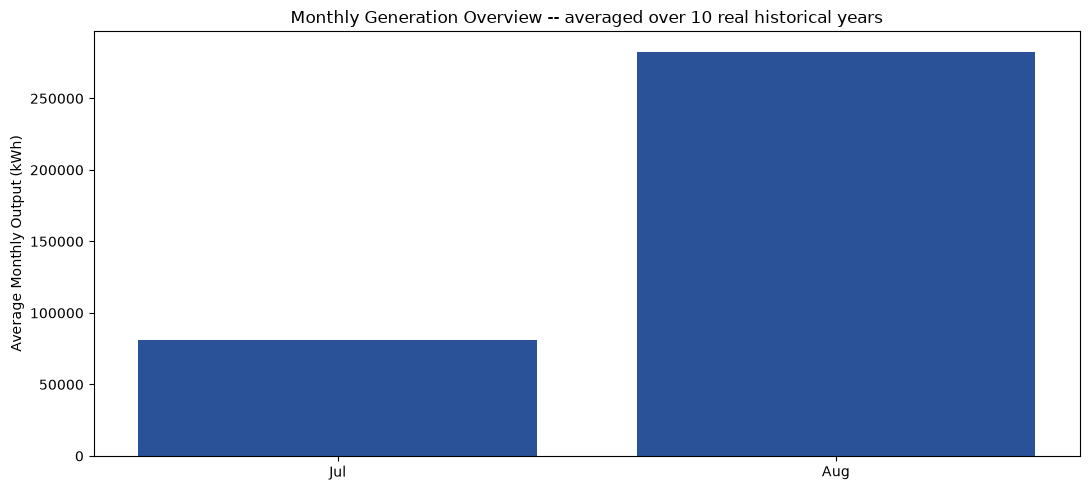

In [15]:
# Monthly bar chart - a bar for each month of the year showing expected output, letting the user see the seasonal shape at a glance
if by_year_results:
    combined_all_years = pd.concat(by_year_results.values(), ignore_index=True)
    monthly_kwh_avg = (
        combined_all_years.assign(month=combined_all_years['DATE_TIME'].dt.month)
        .groupby('month')['COMBINED_AC_KW'].apply(lambda s: s.sum() * 1.0)  # hourly data -> kWh = kW * 1h
        / len(by_year_results)
    )
    month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    monthly_df = monthly_kwh_avg.reindex(range(1, 13)).rename('kwh').reset_index()
    monthly_df['label'] = monthly_df['month'].apply(lambda m: month_names[m - 1])

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(monthly_df['label'], monthly_df['kwh'], color='#2A5298')
    ax.set_ylabel('Average Monthly Output (kWh)')
    ax.set_title(f'Monthly Generation Overview -- averaged over {len(by_year_results)} real historical years')
    plt.tight_layout()
    plt.show()
else:
    print("Monthly bar chart needs a long-range request (>10 days) so multiple historical years get fetched. "
          "This request used the short-term forecast branch instead.")


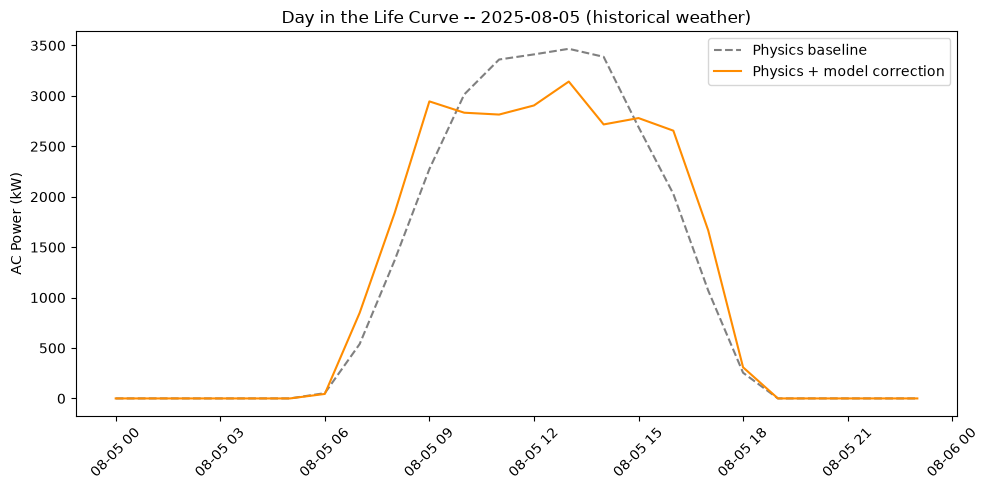

In [16]:
# Day in the life curve - a single sample day's generation curve, rising in the morning, peaking midday, and falling in the evening, giving an intuitive visual of how a typical day behaves
sample_date = primary_df['DATE_TIME'].dt.date.iloc[len(primary_df) // 2]
day_df = primary_df[primary_df['DATE_TIME'].dt.date == sample_date]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(day_df['DATE_TIME'], day_df['THEORETICAL_AC_KW'], label='Physics baseline', color='gray', linestyle='--')
ax.plot(day_df['DATE_TIME'], day_df['COMBINED_AC_KW'], label='Physics + model correction', color='darkorange')
ax.set_title(f'Day in the Life Curve -- {sample_date} ({weather_result["mode"]} weather)')
ax.set_ylabel('AC Power (kW)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


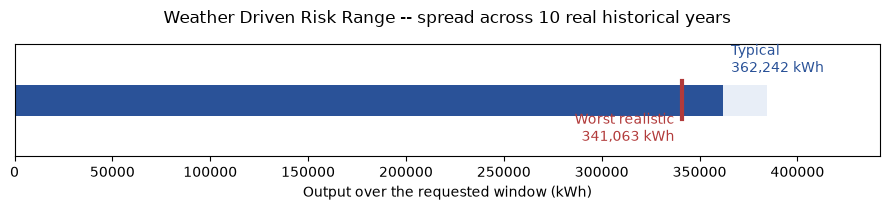

In [17]:
# Risk range gauge - a simple visual showing the gap between the worst realistic case and the typical case, labeled in plain words rather than statistical terms for the simple tier
if by_year_results:
    yearly_totals = pd.Series({yr: df['COMBINED_AC_KW'].sum() * 1.0 for yr, df in by_year_results.items()})
    typical_kwh, worst_kwh, best_kwh = yearly_totals.quantile([0.5, 0.1, 0.9])

    fig, ax = plt.subplots(figsize=(9, 2.2))
    ax.barh(0, best_kwh, color='#E8EEF7', height=0.5)
    ax.barh(0, typical_kwh, color='#2A5298', height=0.5)
    ax.plot([worst_kwh, worst_kwh], [-0.3, 0.3], color='#B23B3B', linewidth=3)
    
    # Check if worst and typical labels are close to prevent horizontal overlapping
    gap = typical_kwh - worst_kwh
    spread = best_kwh if best_kwh > 0 else 1.0
    
    # Adjust vertical positions and alignments dynamically if values are tight
    if (gap / spread) < 0.15:
        typical_ha = 'left'
        worst_ha = 'right'
        typical_x = typical_kwh + (spread * 0.01)
        worst_x = worst_kwh - (spread * 0.01)
    else:
        typical_ha = 'center'
        worst_ha = 'center'
        typical_x = typical_kwh
        worst_x = worst_kwh

    ax.text(typical_x, 0.45, f'Typical\n{typical_kwh:,.0f} kWh', ha=typical_ha, fontsize=10, color='#2A5298')
    ax.text(worst_x, -0.65, f'Worst realistic\n{worst_kwh:,.0f} kWh', ha=worst_ha, fontsize=10, color='#B23B3B')
    
    ax.set_yticks([])
    ax.set_xlabel('Output over the requested window (kWh)')
    ax.set_title(f'Weather Driven Risk Range -- spread across {len(by_year_results)} real historical years', pad=15)
    ax.set_xlim(0, best_kwh * 1.15)
    ax.set_ylim(-0.9, 0.9)
    plt.tight_layout()
    plt.show()
else:
    print("Risk range gauge needs multiple historical years -- not available for short term forecast requests.")


In [18]:
# Quantile table - a table for the advanced tier showing the full P10 through P90 breakdown, by month and by year
if by_year_results:
    all_daily = [
        df.groupby(df['DATE_TIME'].dt.date)['COMBINED_AC_KW'].apply(lambda s: s.sum() * 1.0)
        for df in by_year_results.values()
    ]
    pooled_daily = pd.concat(all_daily)
    q = pooled_daily.quantile([0.1, 0.25, 0.5, 0.75, 0.9])
    quantile_table = pd.DataFrame({
        'Period': [f'{len(by_year_results)} Year Historical Window'],
        'P90': [q[0.1]], 'P75': [q[0.25]], 'P50': [q[0.5]], 'P25': [q[0.75]], 'P10': [q[0.9]],
        'n_days': [len(pooled_daily)],
    })
    display(quantile_table)
else:
    print("Quantile table needs multiple historical years -- not available for short term forecast requests.")


,Period,P90,P75,P50,P25,P10,n_days
0,10 Year Historical Window,21807.005395,24868.245585,26806.251542,27959.389704,28958.393028,140


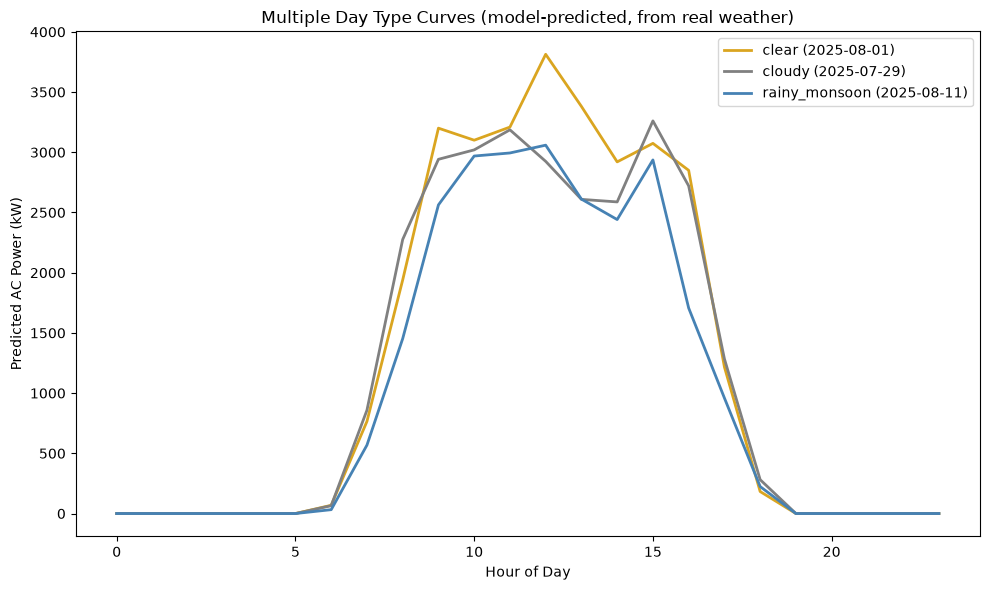

Representative days: {'clear': datetime.date(2025, 8, 1), 'cloudy': datetime.date(2025, 7, 29), 'rainy_monsoon': datetime.date(2025, 8, 11)}


In [19]:
# Multiple day type curves - separate generation curves for a clear day, a cloudy day, and a rainy or monsoon like day, so the advanced user can see the range of daily behavior rather than just one example
daytime_mask = primary_df['IRRADIATION(W/m²)'] > 5
daily_stats = (
    primary_df[daytime_mask]
    .groupby(primary_df['DATE_TIME'].dt.date)['IRRADIATION(W/m²)']
    .agg(mean_irr='mean', std_irr='std')
    .reset_index().rename(columns={'DATE_TIME': 'date'})
)

if len(daily_stats) < 3:
    print(f"Only {len(daily_stats)} day(s) in this request -- need at least a few days to classify day types. "
          "Request a longer time_range_days to see this chart.")
else:
    daily_stats['cv_irr'] = daily_stats['std_irr'] / daily_stats['mean_irr']
    q_low, q_high = daily_stats['mean_irr'].quantile([1 / 3, 2 / 3])

    def classify_day(mean_irr):
        if mean_irr >= q_high:
            return 'clear'
        elif mean_irr >= q_low:
            return 'cloudy'
        return 'rainy_monsoon'

    daily_stats['day_type'] = daily_stats['mean_irr'].apply(classify_day)
    representative_days = {}
    for day_type, group in daily_stats.groupby('day_type'):
        centroid = group[['mean_irr', 'cv_irr']].mean()
        dists = ((group[['mean_irr', 'cv_irr']] - centroid) ** 2).sum(axis=1)
        representative_days[day_type] = group.loc[dists.idxmin(), 'date']

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {'clear': 'goldenrod', 'cloudy': 'gray', 'rainy_monsoon': 'steelblue'}
    for day_type, rep_date in representative_days.items():
        rep_day_df = primary_df[primary_df['DATE_TIME'].dt.date == rep_date]
        hour_dec = rep_day_df['DATE_TIME'].dt.hour + rep_day_df['DATE_TIME'].dt.minute / 60
        ax.plot(hour_dec, rep_day_df['COMBINED_AC_KW'], label=f'{day_type} ({rep_date})',
                color=colors[day_type], linewidth=2)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Predicted AC Power (kW)')
    ax.set_title('Multiple Day Type Curves (model-predicted, from real weather)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("Representative days:", representative_days)


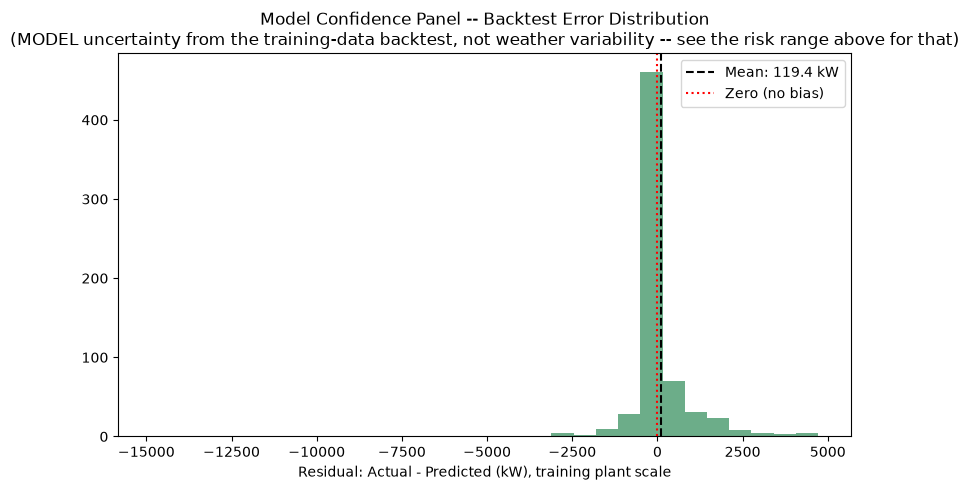

Backtest RMSE=994.4 kW (4.9% of the training plant's 20,230 kWp capacity) | MAE=393.9 kW | R2=0.9761


In [20]:
# Model confidence panel - a small section showing the model's own backtested error range, kept visually separate from the weather risk range so the two types of uncertainty are not confused
relative_backtest_rmse_pct = backtest_rmse_kw / implied_capacity_kwp * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residual_kw, bins=30, color='seagreen', alpha=0.7)
ax.axvline(residual_kw.mean(), color='black', linestyle='--', label=f'Mean: {residual_kw.mean():.1f} kW')
ax.axvline(0, color='red', linestyle=':', label='Zero (no bias)')
ax.set_title('Model Confidence Panel -- Backtest Error Distribution\n'
             '(MODEL uncertainty from the training-data backtest, not weather variability -- see the risk range above for that)')
ax.set_xlabel('Residual: Actual - Predicted (kW), training plant scale')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Backtest RMSE={backtest_rmse_kw:.1f} kW ({relative_backtest_rmse_pct:.1f}% of the training plant's "
      f"{implied_capacity_kwp:,.0f} kWp capacity) | MAE={backtest_mae_kw:.1f} kW | R2={backtest_r2_kw:.4f}")


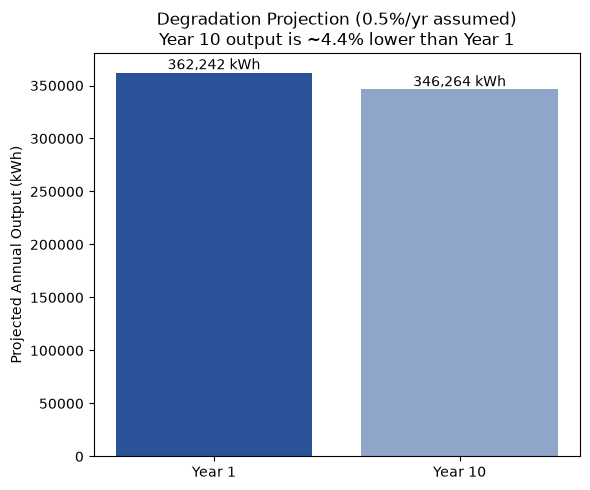

In [21]:
# Degradation projection chart - a chart comparing year one output against a later year, such as year ten, adjusted for panel aging, shown only if the user provided a degradation rate
degradation_rate = USER_INPUTS['degradation_pct_per_year']['value']

if degradation_rate == 0.0 and USER_INPUTS['degradation_pct_per_year']['was_defaulted']:
    print("Degradation projection panel: HIDDEN -- no degradation rate provided, treated as a new system.")
elif by_year_results is None:
    print("Degradation projection needs a multi year horizon -- not applicable to a short term forecast request.")
else:
    rate = degradation_rate / 100.0
    year1_total = pd.Series({yr: df['COMBINED_AC_KW'].sum() * 1.0 for yr, df in by_year_results.items()}).median()
    year10_total = year1_total * ((1 - rate) ** 9)

    fig, ax = plt.subplots(figsize=(6, 5))
    bars = ax.bar(['Year 1', 'Year 10'], [year1_total, year10_total], color=['#2A5298', '#8FA6C9'])
    for b, v in zip(bars, [year1_total, year10_total]):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,.0f} kWh', ha='center', va='bottom')
    pct_drop = (1 - year10_total / year1_total) * 100
    ax.set_ylabel('Projected Annual Output (kWh)')
    ax.set_title(f'Degradation Projection ({degradation_rate}%/yr assumed)\nYear 10 output is ~{pct_drop:.1f}% lower than Year 1')
    plt.tight_layout()
    plt.show()


In [22]:
# Transparency table - a full expandable table of every underlying value used to build the outputs, timestamp, weather inputs, physics number, model correction, and final number, available to any user who wants to dig deeper
transparency_cols = ['DATE_TIME', 'IRRADIATION(W/m²)', 'AMBIENT_TEMPERATURE(°C)', 'WIND_SPEED(m/s)',
                      'CLOUD_COVER(%)', 'THEORETICAL_AC_KW', 'COMBINED_AC_KW']
transparency_table = day_df[transparency_cols].copy()
transparency_table['MODEL_CORRECTION_KW'] = transparency_table['COMBINED_AC_KW'] - transparency_table['THEORETICAL_AC_KW']
transparency_table.columns = ['Timestamp', 'Irradiation (W/m², tilted plane)', 'Ambient Temp (°C)', 'Wind Speed (m/s)',
                               'Cloud Cover (%)', 'Physics Baseline (kW)', 'Final Predicted (kW)', 'Model Correction (kW)']
transparency_table


,Timestamp,"Irradiation (W/m², tilted plane)",Ambient Temp (°C),Wind Speed (m/s),Cloud Cover (%),Physics Baseline (kW),Final Predicted (kW),Model Correction (kW)
168,2025-08-05 00:00:00,0.0,26.2,2.19,95,0.000000,0.000000,0.000000
169,2025-08-05 01:00:00,0.0,26.1,2.26,98,0.000000,0.000000,0.000000
170,2025-08-05 02:00:00,0.0,25.9,2.64,100,0.000000,0.000000,0.000000
171,2025-08-05 03:00:00,0.0,25.7,2.73,100,0.000000,0.000000,0.000000
172,2025-08-05 04:00:00,0.0,25.6,2.77,100,0.000000,0.000000,0.000000
173,2025-08-05 05:00:00,0.0,25.5,2.31,100,0.000000,0.000000,0.000000
174,2025-08-05 06:00:00,10.9,26.5,2.45,100,52.492613,44.561955,-7.930658
175,2025-08-05 07:00:00,113.7,27.4,1.88,99,539.526657,848.849468,309.322812
176,2025-08-05 08:00:00,295.8,28.9,1.81,100,1366.839498,1835.453152,468.613654
177,2025-08-05 09:00:00,505.9,30.6,2.19,100,2274.462303,2945.391556,670.929253


In [23]:
# Suggestions panel - short actionable notes tied to the user's own numbers, for example suggesting appliance timing for a simple tier user or noting financial planning considerations for an advanced tier user
peak_hour = day_df.loc[day_df['COMBINED_AC_KW'].idxmax(), 'DATE_TIME'].strftime('%H:%M')

suggestions = []
if USER_TIER == 'simple':
    suggestions.append(f"Your system is expected to generate the most power around {peak_hour} -- "
                        f"running high-draw appliances near that window uses the most free solar power.")
    if by_year_results:
        spread_pct = (1 - worst_kwh / typical_kwh) * 100
        suggestions.append(f"On a below average period, expect roughly {spread_pct:.0f}% less output than typical -- "
                            f"it's worth having a backup plan rather than assuming every period looks like a good one.")
else:
    suggestions.append(f"Peak generation hour: {peak_hour}. If modeling demand charges or time of use rates, "
                        f"align load shifting incentives around this window.")
    if by_year_results:
        spread_pct = (1 - worst_kwh / typical_kwh) * 100
        suggestions.append( f"Across {len(by_year_results)} historical years, the conservative (P90) case is "
        f"{spread_pct:.0f}% below the typical (P50) case. For financing, base your loan repayment "
        f"calculations on the P90 number, not the P50 average, so you're still covered in a weaker year.")
    if is_out_of_range:
        suggestions.append("This request falls outside the model's May-Jun training window -- treat this "
                            "estimate as directional, not bankable, until validated against more seasons of data.")

print(f"Suggestions ({USER_TIER} tier):")
for s in suggestions:
    print(f"  - {s}")


Suggestions (advanced tier):
  - Peak generation hour: 13:00. If modeling demand charges or time of use rates, align load shifting incentives around this window.
  - Across 10 historical years, the conservative (P90) case is 6% below the typical (P50) case. For financing, base your loan repayment calculations on the P90 number, not the P50 average, so you're still covered in a weaker year.
  - This request falls outside the model's May-Jun training window -- treat this estimate as directional, not bankable, until validated against more seasons of data.


In [24]:
# Risk and caveats panel - a dedicated space listing anything relevant to trustworthiness, including the out of range warning, the list of which fields were defaulted, and a plain explanation of what P50 and P90 mean
caveats = [
    "Training window for the correction model: May 15 - Jun 17, 2020, single plant, single region "
    "(monsoon season). The physics baseline generalizes to any location/season; the model correction "
    "is validated only within that window.",
    f"Confidence: {confidence_label}",
    "P50 = the 'typical' outcome: half of periods produce more than this, half less.",
    "P90 = a conservative planning figure: 90% of periods produce at least this much.",
]
if is_out_of_range:
    caveats.insert(0, "WARNING: " + "; ".join(out_of_range_reasons))
caveats += [f"Defaulted: {n}" for n in assumption_notes]

print("Risk and caveats panel:")
for c in caveats:
    print(f"  - {c}")


Risk and caveats panel:
  - WARNING: requested period falls outside the May-Jun training window
  - Training window for the correction model: May 15 - Jun 17, 2020, single plant, single region (monsoon season). The physics baseline generalizes to any location/season; the model correction is validated only within that window.
  - Confidence: Lower confidence -- most optional fields are using typical defaults, not your actual system specs.
  - P50 = the 'typical' outcome: half of periods produce more than this, half less.
  - P90 = a conservative planning figure: 90% of periods produce at least this much.
  - Defaulted: tilt_deg: Defaults to the location's latitude once geocoded. Set to 13.1 deg (this location's latitude).
  - Defaulted: azimuth_deg: Defaults to true south (0 deg) in the northern hemisphere or true north (180 deg) in the southern hemisphere. Set to 0.0 deg -- northern (south facing, 0 deg) hemisphere default.
  - Defaulted: inverter_efficiency: Defaults to a typical inve

In [25]:
# Input summary tab - a tab or panel showing back exactly what the user entered and what was defaulted, so they can review and correct it without having to redo the whole input process
input_summary_df = pd.DataFrame([
    {'Field': field, 'Value Used': info['value'],
     'Source': 'Defaulted' if info['was_defaulted'] else 'User provided', 'Note': info['note']}
    for field, info in USER_INPUTS.items()
])
input_summary_df


,Field,Value Used,Source,Note
0,location,"Chennai, India",User provided,User provided location.
1,capacity_kwp,5000.0,User provided,User provided system size.
2,time_range_days,14,User provided,User-chosen estimate horizon.
3,tilt_deg,13.1,Defaulted,Defaults to the location's latitude once geoco...
4,azimuth_deg,0.0,Defaulted,Defaults to true south (0 deg) in the northern...
5,inverter_efficiency,0.97,Defaulted,Defaults to a typical inverter efficiency of 97%.
6,temp_coefficient,-0.004,Defaulted,Defaults to a typical crystalline silicon valu...
7,degradation_pct_per_year,0.5,User provided,User provided degradation rate.


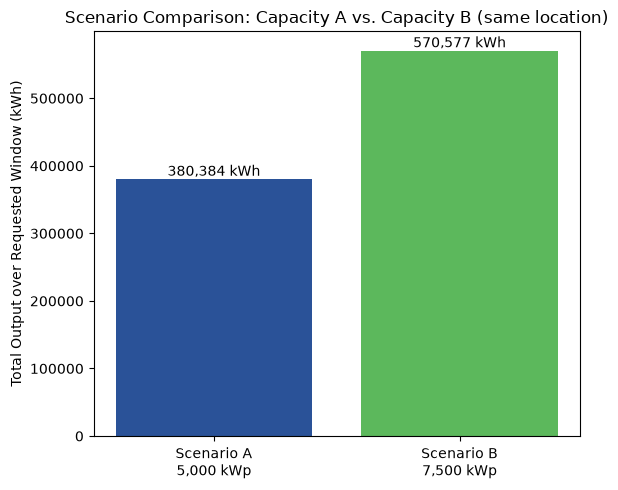

In [26]:
# Comparison tab - an optional tab letting the user compare two different input scenarios side by side, for example comparing their system at two different capacities or two different locations
scenario_a_kwh = primary_df['COMBINED_AC_KW'].sum() * 1.0
scenario_b_kwp = USER_INPUTS['capacity_kwp']['value'] * 1.5
scenario_b_kwh = (primary_df['COMBINED_AC_PER_KWP'] * scenario_b_kwp).sum() * 1.0

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar([f"Scenario A\n{USER_INPUTS['capacity_kwp']['value']:,.0f} kWp",
               f"Scenario B\n{scenario_b_kwp:,.0f} kWp"],
              [scenario_a_kwh, scenario_b_kwh], color=['#2A5298', '#5CB85C'])
for b, v in zip(bars, [scenario_a_kwh, scenario_b_kwh]):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,.0f} kWh', ha='center', va='bottom')
ax.set_ylabel('Total Output over Requested Window (kWh)')
ax.set_title('Scenario Comparison: Capacity A vs. Capacity B (same location)')
plt.tight_layout()
plt.show()


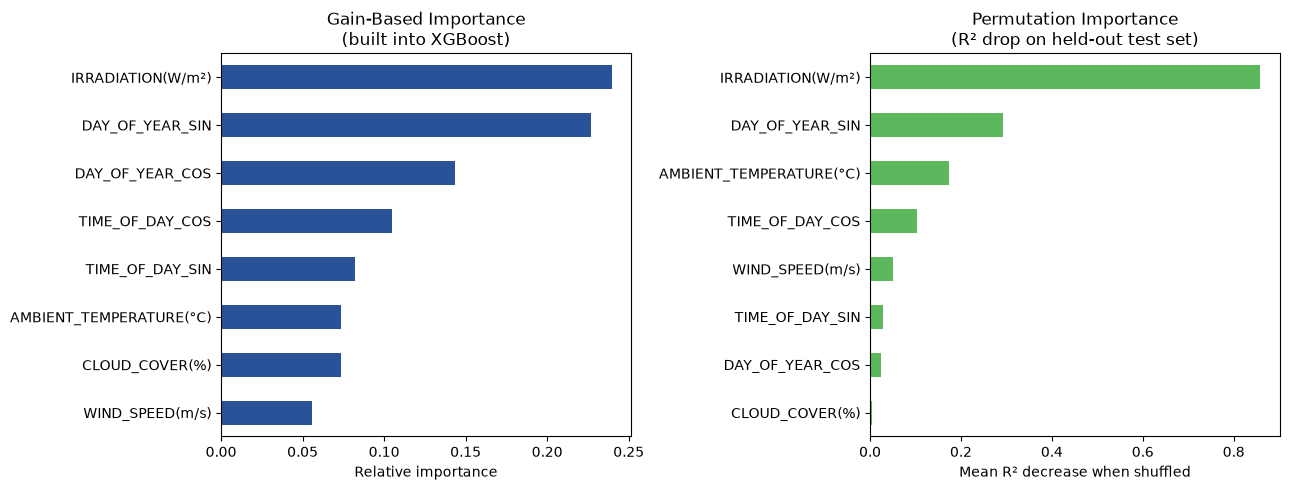

Gain-based importance:
IRRADIATION(W/m²)          0.239462
DAY_OF_YEAR_SIN            0.227088
DAY_OF_YEAR_COS            0.143450
TIME_OF_DAY_COS            0.105127
TIME_OF_DAY_SIN            0.082093
AMBIENT_TEMPERATURE(°C)    0.073673
CLOUD_COVER(%)             0.073460
WIND_SPEED(m/s)            0.055648

Permutation importance (R2 drop):
IRRADIATION(W/m²)          0.858906
DAY_OF_YEAR_SIN            0.292178
AMBIENT_TEMPERATURE(°C)    0.173800
TIME_OF_DAY_COS            0.102452
WIND_SPEED(m/s)            0.050053
TIME_OF_DAY_SIN            0.028969
DAY_OF_YEAR_COS            0.023398
CLOUD_COVER(%)             0.003699


In [27]:
# Feature importance
from sklearn.inspection import permutation_importance

# Built-in XGBoost gain importance -- how much each feature reduces training error
gain_importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)

# Permutation importance -- shuffle each feature on held out data and measure the resulting drop in R2
perm_result = permutation_importance(
    xgb_model, X_test, y_test, n_repeats=15, random_state=42, scoring='r2'
)
perm_importance = pd.Series(perm_result.importances_mean, index=features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
gain_importance.sort_values().plot(kind='barh', ax=axes[0], color='#2A5298')
axes[0].set_title('Gain-Based Importance\n(built into XGBoost)')
axes[0].set_xlabel('Relative importance')

perm_importance.sort_values().plot(kind='barh', ax=axes[1], color='#5CB85C')
axes[1].set_title('Permutation Importance\n(R² drop on held-out test set)')
axes[1].set_xlabel('Mean R² decrease when shuffled')

plt.tight_layout()
plt.show()

print("Gain-based importance:")
print(gain_importance.to_string())
print("\nPermutation importance (R2 drop):")
print(perm_importance.to_string())